<a href="https://colab.research.google.com/github/CMDDclass/MS697-material/blob/main/2_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-driven Materials Development

In this notebook, we'll use a GPU for faster model training.

To enable the GPU:

1. Navigate to Runtime.

2. Select Change runtime type.

3. Choose T4 GPU from the dropdown menu.

4. Click Save.

# VAE (Variational Autoencoder)

A Variational Autoencoder (VAE) is a generative model that learns to compress (encode) data into a probabilistic low-dimensional latent space and then generate (decode) new data from it.

It consists of two main components:

1. Encoder ($q(z|x)$):

- Unlike a standard autoencoder, the encoder does not map an input $x$ to a single point.

- Instead, it maps the input $x$ to a probability distribution (a "latent space") described by its mean ($\mu$) and log-variance ($\log(\sigma^2)$).

- This probabilistic mapping ensures the latent space is continuous and structured.

2. Decoder ($p(x|z)$):

- A point $z$ is sampled from the latent distribution (using the $\mu$ and $\log(\sigma^2)$ from the encoder via the "reparameterization trick").

- The decoder then takes this latent point $z$ and attempts to reconstruct the original input $x$.

# Learning Objective (Loss Function)

The VAE is trained by optimizing a single loss function, which is the sum of two competing terms. This is derived from maximizing the Evidence Lower Bound (ELBO) on the data likelihood.

1. Reconstruction Loss:

- Goal: Make the reconstructed image $x'$ as similar as possible to the original image $x$.

- How: This term measures the difference between the input and the output. It is typically the Binary Crossentropy (BCE) or Mean Squared Error (MSE).

- $L_{\text{reconstruction}} = E_{q(z|x)}[\log p(x|z)]$

- Kullback-Leibler (KL) Divergence:Goal: Act as a regularizer to organize the latent space.

- How: It forces the distributions $q(z|x)$ learned by the encoder to be, on average, close to a standard normal distribution ($p(z) \sim N(0, I)$).

- This prevents overfitting and ensures that points near each other in the latent space produce similar-looking outputs, which is what allows the VAE to generate new, realistic data.

- $L_{\text{KL}} = D_{\text{KL}}(q(z|x) || p(z))$

Total Loss = Reconstruction Loss + KL Divergence

The model must learn to balance these two terms: it must encode the data well enough to reconstruct it accurately, but not so well that it breaks the smooth, regular structure of the latent space.



In [5]:
# 0. Check GPU status
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
!nvidia-smi

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Oct 31 05:56:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |     

In [1]:
# 1. Library Imports and Environment Setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.losses import mse, binary_crossentropy
from tensorflow.keras.utils import plot_model
from scipy.stats import norm

In [2]:
# 2. Load and Preprocess MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
image_size = x_train.shape[1]
original_dim = image_size * image_size
x_train = np.reshape(x_train, [-1, original_dim]).astype('float32') / 255
x_test = np.reshape(x_test, [-1, original_dim]).astype('float32') / 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# 3. Model Hyperparameter Setup
input_shape = (original_dim,)
intermediate_dim = 512
batch_size = 128
latent_dim = 2
epochs = 10

In [4]:
# 4. Reparameterization Trick
def sampling(args):
    """
    Reparameterization trick by sampling from an isotropic unit Gaussian.
    # Arguments:
        args (tensor): mean and log of variance of Q(z|X)
    # Returns:
        z (tensor): sampled latent vector
    """
    z_mean, z_log_var = args
    batch = keras.ops.shape(z_mean)[0]
    dim = keras.ops.shape(z_mean)[1]
    # by default, random_normal has mean=0 and std=1.0
    epsilon = keras.random.normal(shape=(batch, dim))
    return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

In [6]:
# 5. Encoder Function Definition
def build_encoder(input_shape, intermediate_dim, latent_dim):
    """
    Builds and returns the VAE encoder model.
    (Input) -> Dense -> (z_mean, z_log_var) -> z
    """
    inputs = Input(shape=input_shape, name='encoder_input')
    x = Dense(intermediate_dim, activation='relu')(inputs)
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

    # Create Keras Model object
    encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
    return encoder

In [7]:
# 6. Decoder Function Definition
def build_decoder(intermediate_dim, original_dim, latent_dim):
    """
    Builds and returns the VAE decoder model.
    (Latent Input) -> Dense -> (Output Image)
    """
    latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
    x = Dense(intermediate_dim, activation='relu')(latent_inputs)
    outputs = Dense(original_dim, activation='sigmoid')(x)

    # Create Keras Model object
    decoder = Model(latent_inputs, outputs, name='decoder')
    return decoder

In [8]:
# 7. VAE Model Class Definition (Same as before)
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, data):
        """Defines the forward pass for inference."""
        _, _, z = self.encoder(data)
        reconstruction = self.decoder(z)
        return reconstruction

    def _compute_loss(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = keras.ops.sum(
            keras.ops.binary_crossentropy(data, reconstruction), axis=-1
        )
        kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
        kl_loss = keras.ops.sum(kl_loss, axis=-1)
        total_loss = keras.ops.mean(reconstruction_loss + kl_loss)
        return total_loss, keras.ops.mean(reconstruction_loss), keras.ops.mean(kl_loss)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_loss(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        total_loss, reconstruction_loss, kl_loss = self._compute_loss(data)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [9]:
# 8. Build and Compile Models
print("--- Building Encoder ---")
encoder = build_encoder(input_shape, intermediate_dim, latent_dim)
encoder.summary()

print("\n--- Building Decoder ---")
decoder = build_decoder(intermediate_dim, original_dim, latent_dim)
decoder.summary()

# Instantiate VAE model
vae = VAE(encoder, decoder)


# Compile and Train
vae.compile(optimizer='adam')
vae.fit(x_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, None))

--- Building Encoder ---


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    401,920 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │      1,026 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │      1,026 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 403,972 (1.54 MB)

 Trainable params: 403,972 (1.54 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,728 (1.54 MB)

 Trainable params: 403,728 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

"\n# Compile and Train\nvae.compile(optimizer='adam')\nvae.fit(x_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, None))\n\n"

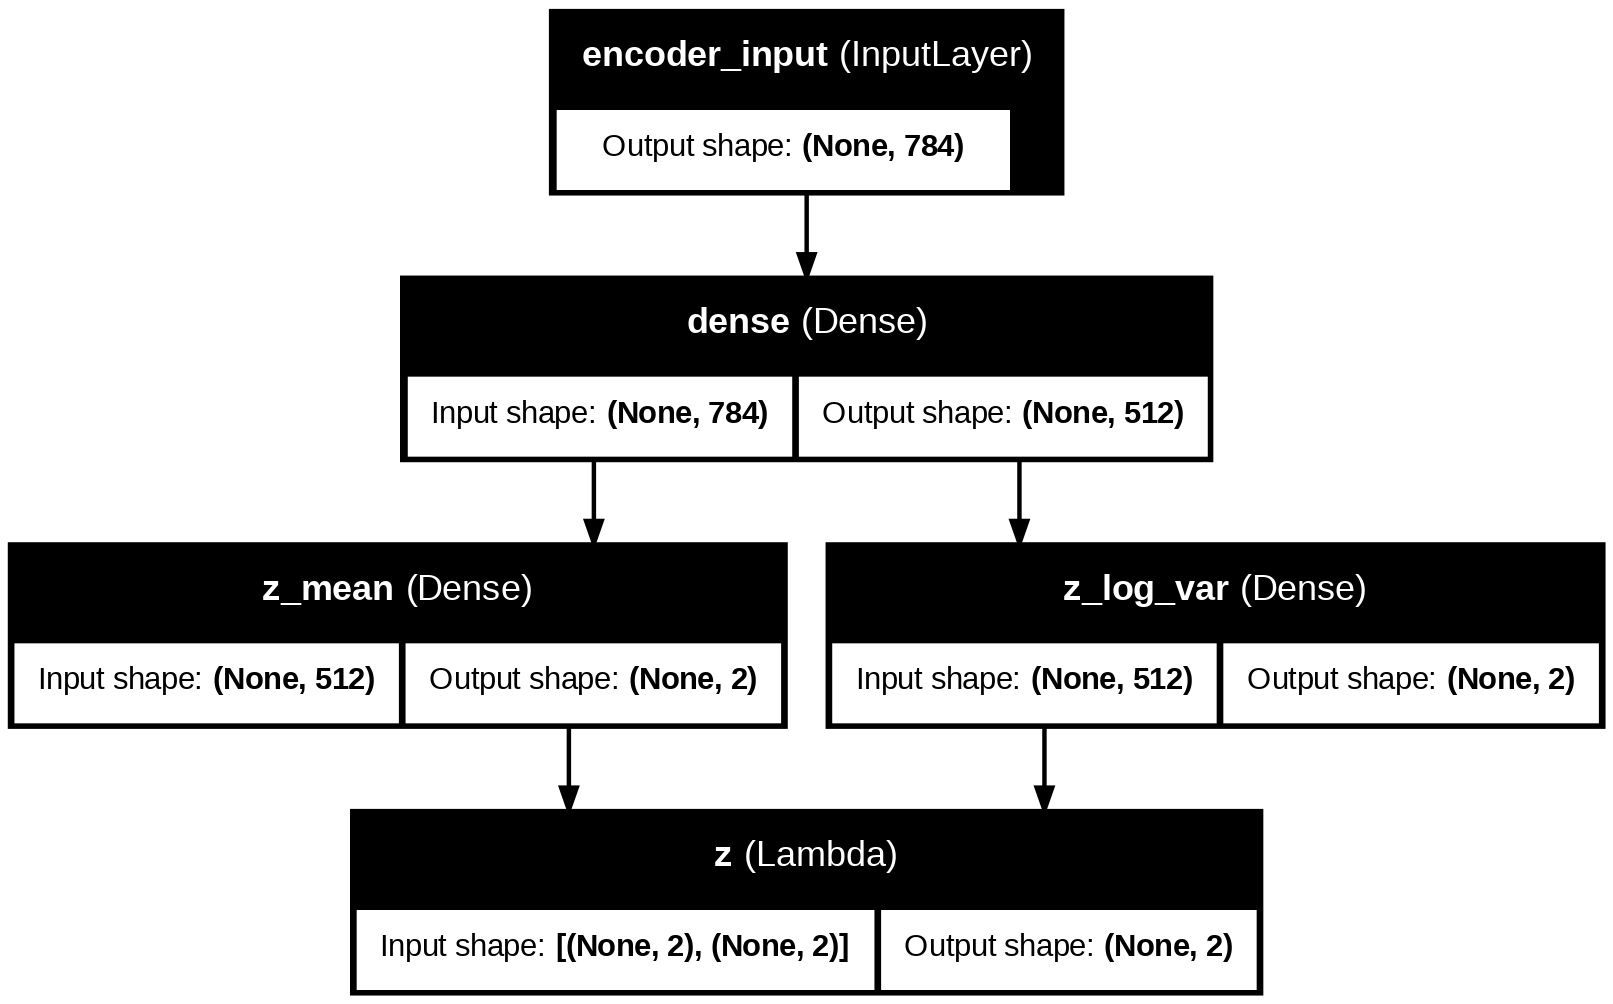

In [15]:
plot_model(
    encoder,
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",   # TB: 위->아래, LR: 좌->우
    dpi=160
)


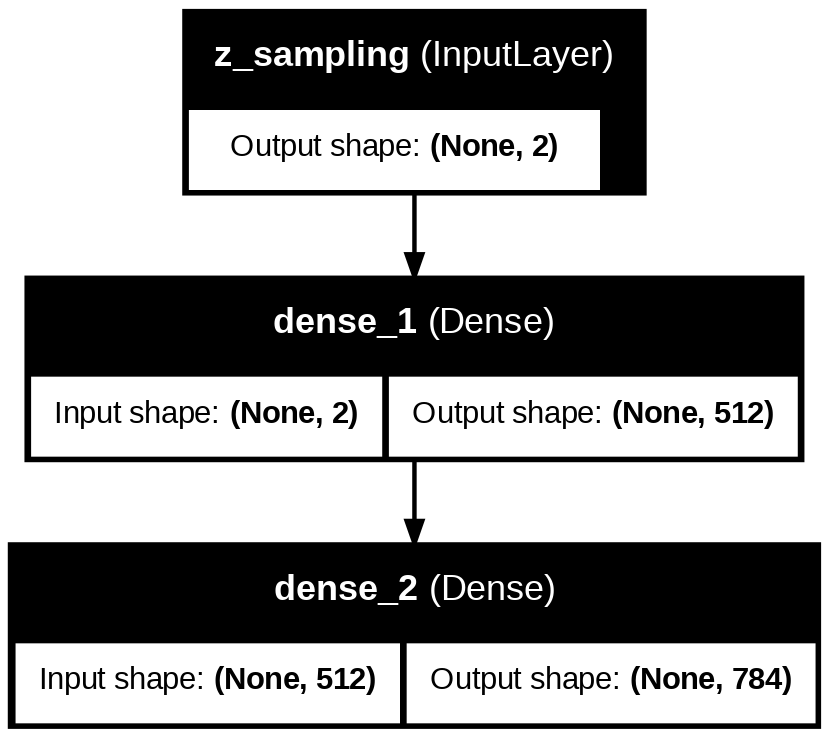

In [17]:
plot_model(
    decoder,
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",   # TB: 위->아래, LR: 좌->우
    dpi=160
)


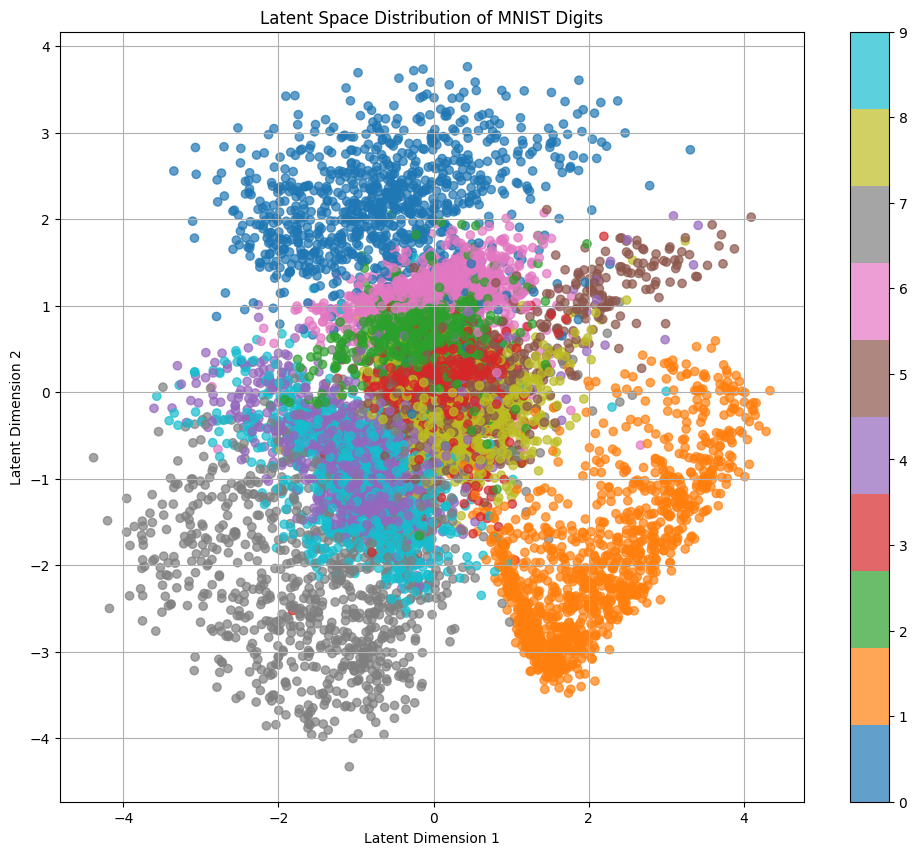

In [ ]:
def plot_label_clusters(vae, data, labels):
    """
    Plots the distribution of test data in the 2D latent space.
    """
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.colorbar(ticks=range(10))
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title("Latent Space Distribution of MNIST Digits")
    plt.grid(True)
    plt.show()
plot_label_clusters(vae, x_test, y_test)

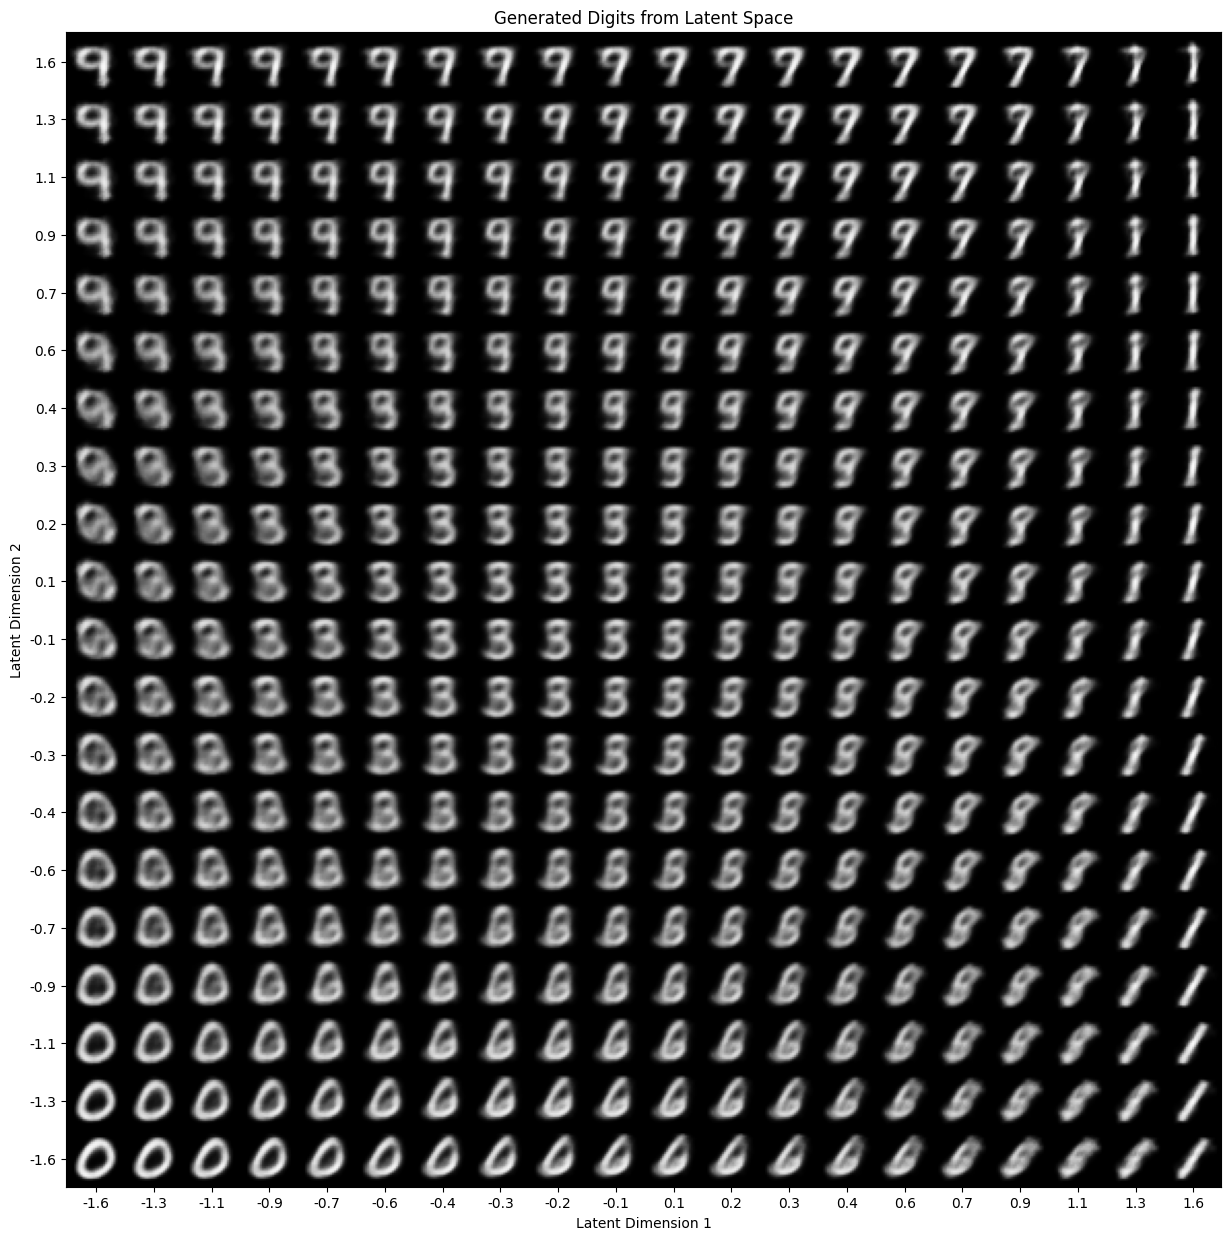

In [ ]:
def plot_latent_space(vae, n=20, figsize=15):
    """
    Generates and plots a 2D manifold of digits from the latent space.
    """
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
    grid_y = norm.ppf(np.linspace(0.05, 0.95, n))[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title("Generated Digits from Latent Space")
    plt.imshow(figure, cmap='Greys_r')
    plt.show()
plot_latent_space(vae)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


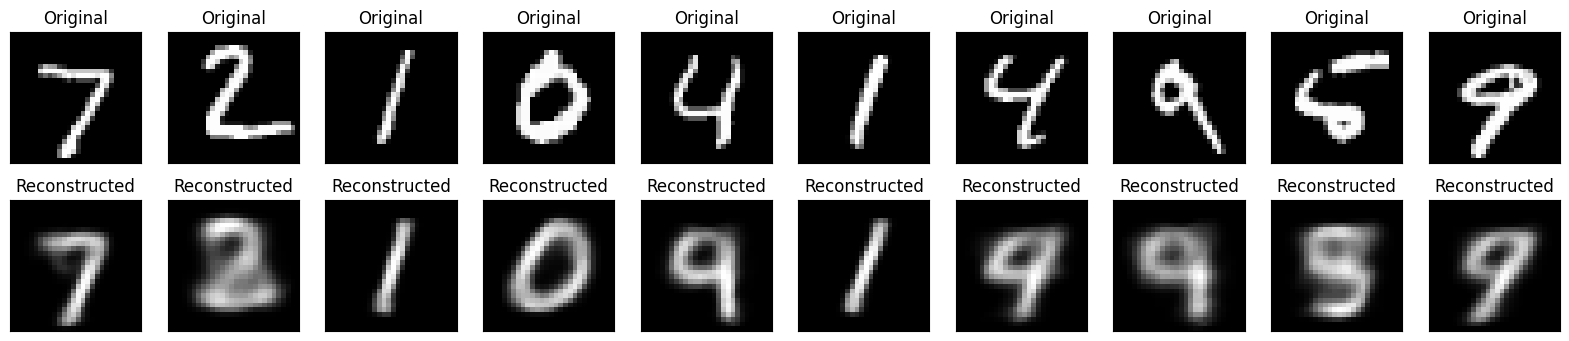

In [ ]:
x_decoded = vae.predict(x_test, batch_size=batch_size)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_decoded[i].reshape(28, 28))
    plt.title("Reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Practice: Tune VAE Hyperparameters

In this section, we experiment with different hyperparameters of the Variational Autoencoder and observe how they affect the reconstruction quality and latent space structure.

We encourage you to run multiple settings and compare your results!


| Hyperparameter   | Description                               | Suggested Values       | Expected Effect |
|-----------------|-------------------------------------------|------------------------|----------------|
| intermediate_dim | Size of the hidden (dense) layer          | 256 / 512 / 1024       | Larger → more expressive encoder/decoder → clearer reconstructions |
| batch_size       | Number of samples per gradient update     | 64 / 128 / 256         | Smaller → noisy updates, maybe better generalization but slower |
| latent_dim       | Dimensionality of the latent space        | 2 / 8 / 16             | Larger → more information preserved → better reconstructions but harder to visualize |
| epochs           | Number of training iterations             | 20 / 40 / 60           | Longer → more convergence → reduced reconstruction error |

### **Submit the following as your practice result:

• A **clear example of reconstructed digit images from the MNIST test data.

• The hyperparameter set (intermediate_dim / batch_size / latent_dim / epochs) that produced the shown results.

• The corresponding latent space distribution plot.

------------------------------------------------------------------------------------------
Starting Experiment with: latent_dim=8, intermediate_dim=512, epochs=30
------------------------------------------------------------------------------------------
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - kl_loss: 16.0367 - loss: 253.8989 - reconstruction_loss: 237.8622 - val_kl_loss: 14.8981 - val_loss: 145.3542 - val_reconstruction_loss: 130.4562
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - kl_loss: 14.5088 - loss: 141.4511 - reconstruction_loss: 126.9423 - val_kl_loss: 15.0224 - val_loss: 130.5417 - val_reconstruction_loss: 115.5193
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - kl_loss: 14.5933 - loss: 130.3524 - reconstruction_loss: 115.7591 - val_kl_loss: 14.7822 - val_loss: 125.5999 - val_reconstruction_loss: 110.8177
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - kl_loss: 14.6799 - loss: 125.9870 - reconstruction_loss: 111.3072 - val_kl_loss: 14.6126 -

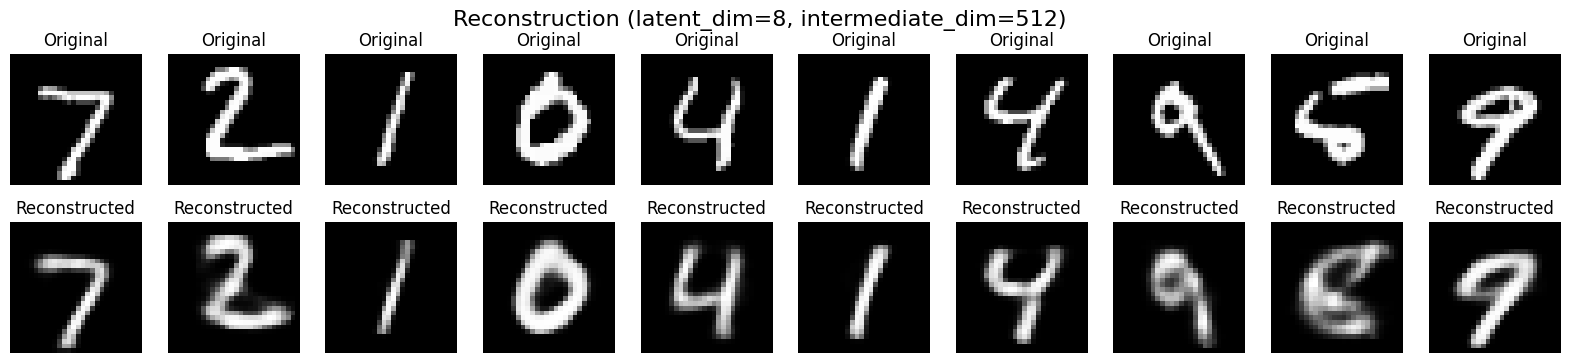

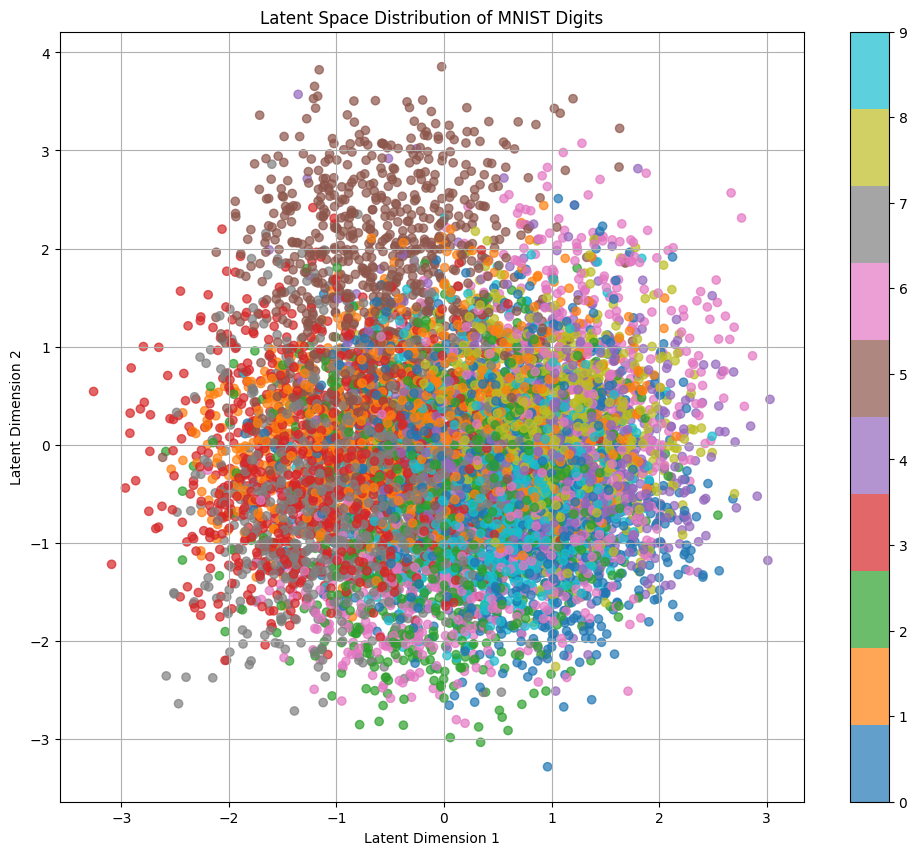

In [ ]:
def run_vae_experiment(latent_dim=2, batch_size=128, intermediate_dim=512, epochs=10):
    """
    Runs a complete VAE experiment with given hyperparameters and visualizes the results.
    """
    print("---" * 30)
    print(f"Starting Experiment with: latent_dim={latent_dim}, intermediate_dim={intermediate_dim}, epochs={epochs}")
    print("---" * 30)

    # 1. Build Models
    encoder = build_encoder(input_shape, intermediate_dim, latent_dim)
    decoder = build_decoder(intermediate_dim, original_dim, latent_dim)
    vae = VAE(encoder, decoder)

    # 2. Compile and Train
    vae.compile(optimizer='adam')
    history = vae.fit(x_train,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_data=(x_test, None),
                      verbose=1)

    print("Training Finished.")

    # 3. Quantitative Analysis: Print final loss values
    val_loss = history.history['val_loss'][-1]
    print(f"  - Final Validation Loss: {val_loss:.4f}")

    # 4. Qualitative Analysis: Visualize results
    print("  - Visualizing results...")

    # Reconstruction quality
    x_decoded = vae.predict(x_test, batch_size=batch_size, verbose=0)
    n = 10
    plt.figure(figsize=(20, 4))
    plt.suptitle(f"Reconstruction (latent_dim={latent_dim}, intermediate_dim={intermediate_dim})", fontsize=16)
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        ax.set_title("Original")
        ax.axis('off')
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_decoded[i].reshape(28, 28), cmap='gray')
        ax.set_title("Reconstructed")
        ax.axis('off')
    plt.show()


    plot_label_clusters(vae, x_test, y_test)


    return history, vae

# You can change here-----------------------------------------------------------------------
latent_dim = 8
batch_size = 256
intermediate_dim = 512
epochs = 30
# ------------------------------------------------------------------------------------------
history, vae = run_vae_experiment(latent_dim, batch_size, intermediate_dim, epochs)
